In [1]:
from google.colab import files
files.upload()

Saving kaggle.json to kaggle.json


{'kaggle.json': b'{"username":"ayshahaneena","key":"8bca9a7a54abc38456202caa3663564b"}'}

In [2]:
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

In [3]:
! pip install -q kaggle # installing command line interface

In [4]:
# download the dataset
! kaggle datasets download -d vipoooool/new-plant-diseases-dataset

Dataset URL: https://www.kaggle.com/datasets/vipoooool/new-plant-diseases-dataset
License(s): copyright-authors


In [5]:
# to unzip the dataset
! unzip new-plant-diseases-dataset.zip -d plant-disease-dataset

Streaming output truncated to the last 5000 lines.
  inflating: plant-disease-dataset/new plant diseases dataset(augmented)/New Plant Diseases Dataset(Augmented)/valid/Strawberry___healthy/273a7a9e-18be-4b6a-976a-fa5ffd69b731___RS_HL 4366_90deg.JPG  
  inflating: plant-disease-dataset/new plant diseases dataset(augmented)/New Plant Diseases Dataset(Augmented)/valid/Strawberry___healthy/275f8963-f4f4-4903-962b-1da716725d08___RS_HL 4780_90deg.JPG  
  inflating: plant-disease-dataset/new plant diseases dataset(augmented)/New Plant Diseases Dataset(Augmented)/valid/Strawberry___healthy/275f8963-f4f4-4903-962b-1da716725d08___RS_HL 4780_new30degFlipLR.JPG  
  inflating: plant-disease-dataset/new plant diseases dataset(augmented)/New Plant Diseases Dataset(Augmented)/valid/Strawberry___healthy/27c2aaa4-de4b-4fb1-ba8d-14d4b24b2afa___RS_HL 4665.JPG  
  inflating: plant-disease-dataset/new plant diseases dataset(augmented)/New Plant Diseases Dataset(Augmented)/valid/Strawberry___healthy/27c2aaa4

In [6]:
import os   # operating system module

data_directory = "plant-disease-dataset"
print(os.listdir(data_directory)[:5]) # first 5 categories

['new plant diseases dataset(augmented)', 'New Plant Diseases Dataset(Augmented)', 'test']


full_path = os.path.join(base_path, folder) , Joins folder paths safely

In [7]:
augmented_directory = os.path.join(data_directory, "New Plant Diseases Dataset(Augmented)")
print(os.listdir(augmented_directory)[:5])

['New Plant Diseases Dataset(Augmented)']


In [8]:
# Go deeper into the nested folder
nested_dir = os.path.join(data_directory,
    "New Plant Diseases Dataset(Augmented)",
    "New Plant Diseases Dataset(Augmented)")

# Check what's inside
print(os.listdir(nested_dir))


['train', 'valid']


In [9]:
train_directory = os.path.join(nested_dir, 'train')
print(os.listdir(train_directory))

['Peach___healthy', 'Tomato___Early_blight', 'Corn_(maize)___healthy', 'Squash___Powdery_mildew', 'Tomato___Late_blight', 'Grape___healthy', 'Grape___Leaf_blight_(Isariopsis_Leaf_Spot)', 'Strawberry___Leaf_scorch', 'Apple___Cedar_apple_rust', 'Tomato___Bacterial_spot', 'Soybean___healthy', 'Corn_(maize)___Northern_Leaf_Blight', 'Tomato___Spider_mites Two-spotted_spider_mite', 'Apple___Black_rot', 'Tomato___Tomato_mosaic_virus', 'Potato___Early_blight', 'Apple___Apple_scab', 'Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot', 'Pepper,_bell___healthy', 'Tomato___healthy', 'Apple___healthy', 'Raspberry___healthy', 'Corn_(maize)___Common_rust_', 'Strawberry___healthy', 'Cherry_(including_sour)___Powdery_mildew', 'Tomato___Tomato_Yellow_Leaf_Curl_Virus', 'Grape___Black_rot', 'Tomato___Target_Spot', 'Tomato___Septoria_leaf_spot', 'Potato___Late_blight', 'Grape___Esca_(Black_Measles)', 'Cherry_(including_sour)___healthy', 'Potato___healthy', 'Tomato___Leaf_Mold', 'Blueberry___healthy', 'Pea

In [10]:
class_names = sorted(os.listdir(train_directory))
print(f"Number of classes: {len(class_names)}")

Number of classes: 38


### LOAD DATA

It loads labeled images from a directory and splits it into training and validation sets automatically, using TensorFlow's built-in image_dataset_from_directory.

In [11]:
!pip install tensorflow

In [12]:
import tensorflow as tf
# resize all images
image_height = 128
image_width = 128
batch_size = 16   # Loads 32 images per batch for efficient training


train_ds = tf.keras.utils.image_dataset_from_directory(
    train_directory,
    validation_split=0.2,
    subset='training',
    seed=123,
    image_size= (image_height, image_width),
    batch_size=batch_size
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    train_directory,
    validation_split=0.2,
    subset='validation',
    seed=123,
    image_size=(image_height, image_width),
    batch_size=batch_size
)

Found 70295 files belonging to 38 classes.
Using 56236 files for training.
Found 70295 files belonging to 38 classes.
Using 14059 files for validation.


In [13]:
class_names = train_ds.class_names
print(class_names)
print(len(class_names))

['Apple___Apple_scab', 'Apple___Black_rot', 'Apple___Cedar_apple_rust', 'Apple___healthy', 'Blueberry___healthy', 'Cherry_(including_sour)___Powdery_mildew', 'Cherry_(including_sour)___healthy', 'Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot', 'Corn_(maize)___Common_rust_', 'Corn_(maize)___Northern_Leaf_Blight', 'Corn_(maize)___healthy', 'Grape___Black_rot', 'Grape___Esca_(Black_Measles)', 'Grape___Leaf_blight_(Isariopsis_Leaf_Spot)', 'Grape___healthy', 'Orange___Haunglongbing_(Citrus_greening)', 'Peach___Bacterial_spot', 'Peach___healthy', 'Pepper,_bell___Bacterial_spot', 'Pepper,_bell___healthy', 'Potato___Early_blight', 'Potato___Late_blight', 'Potato___healthy', 'Raspberry___healthy', 'Soybean___healthy', 'Squash___Powdery_mildew', 'Strawberry___Leaf_scorch', 'Strawberry___healthy', 'Tomato___Bacterial_spot', 'Tomato___Early_blight', 'Tomato___Late_blight', 'Tomato___Leaf_Mold', 'Tomato___Septoria_leaf_spot', 'Tomato___Spider_mites Two-spotted_spider_mite', 'Tomato___Target_Sp

### VISUALIZE THE DATASET

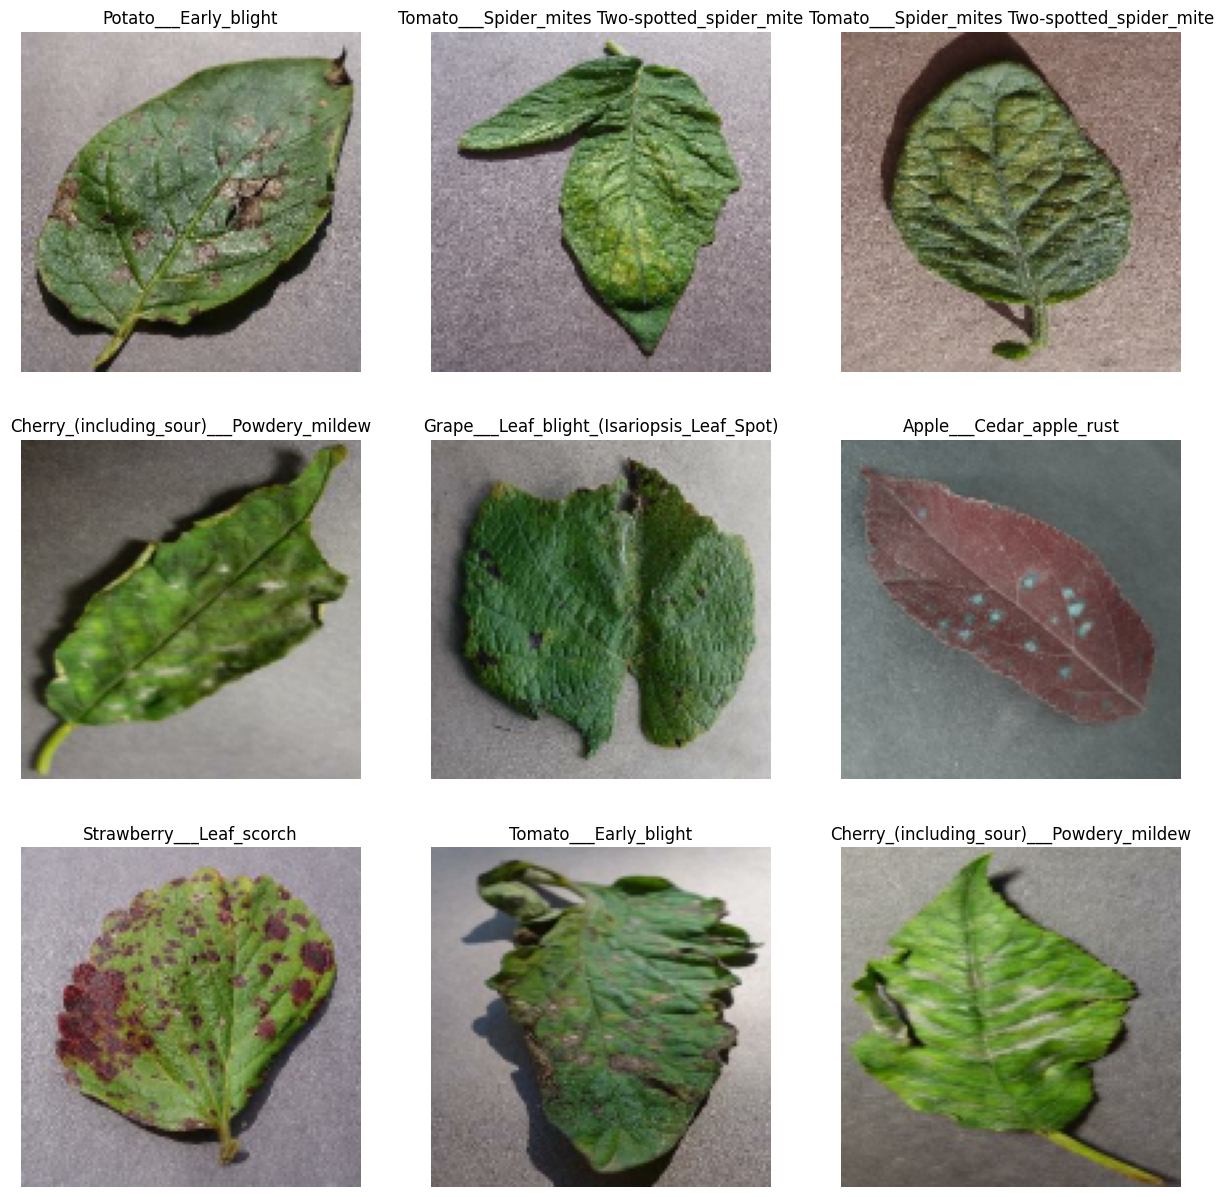

In [14]:
import matplotlib.pyplot as plt
plt.figure(figsize=(15,15))

for images , labels in train_ds.take(1): # taking 1 batch
  for i in range(9):
    ax = plt.subplot(3,3,i+1)
    plt.imshow(images[i].numpy().astype('uint8')) # converting to tf tensor to numpy array
                                                  # converting image pixels to 8-bit integers (0-255) for display
    plt.title(class_names[labels[i]])
    plt.axis('off')

### CONFIGURE DATASET FOR PERFORMANCE

A data pipeline is the complete process of loading, processing, and feeding data to your model during training and evaluation.

In [15]:
# tensorflow data pipeline
AUTOTUNE = tf.data.AUTOTUNE

train_ds = train_ds.shuffle(1000).prefetch(buffer_size=AUTOTUNE)
val_ds = val_ds.prefetch(buffer_size=AUTOTUNE)

### tf.data.AUTOTUNE is a smart performance setting.
- cache() - Stores the preprocessed data in memory or on disk
➡️ So TensorFlow doesn’t repeat the heavy work every epoch
- shuffle(1000) - Randomizes the order of samples in each epoch
✅ Prevents the model from memorizing the order
- prefetch(buffer_size=AUTOTUNE) - Prepares the next batch while the model is training on the current one and buffer_size refers How many batches to prepare in advance while the model is still training on the current batch.

Think of it like a deck of cards: You're shuffling 1000 cards instead of the whole deck to save time and memory.

 Larger buffer = better randomness, but uses more memory.

In [16]:
# shape of datasets
for image , label in train_ds.take(1): # taking only 1 batch which is 32
    print("shape of image: ", image.shape)
    print("shape of label: ", label.shape)

shape of image:  (16, 128, 128, 3)
shape of label:  (16,)


## DEFINING CNN MODEL

In [17]:
model = tf.keras.Sequential([
    tf.keras.layers.Rescaling(1./255, input_shape=(image_height,image_width, 3)), # Rescaling Layer: Normalizes pixel values from [0, 255] → [0, 1] by dividing by 255.

    tf.keras.layers.Conv2D(32, 3, activation='relu'),
    tf.keras.layers.MaxPooling2D(),

    tf.keras.layers.Conv2D(64, 3, activation='relu'),
    tf.keras.layers.MaxPooling2D(),

    tf.keras.layers.Conv2D(128, 3, activation='relu'),
    tf.keras.layers.MaxPooling2D(),
    tf.keras.layers.Dropout(0.3),


    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(128, activation='relu'),
    tf.keras.layers.Dropout(0.5),
    tf.keras.layers.Dense(len(class_names), activation='softmax')
])

/usr/local/lib/python3.11/dist-packages/keras/src/layers/preprocessing/tf_data_layer.py:19: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


### COMPILE THE MODEL

In [18]:
model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

In [19]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling (Rescaling)           │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 126, 126, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 61, 61, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 28, 28, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     3,211,392 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 38)             │         4,902 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,309,542 (12.62 MB)

 Trainable params: 3,309,542 (12.62 MB)

 Non-trainable params: 0 (0.00 B)

### MODEL TRAINING


In [20]:
# early stopping
from tensorflow.keras.callbacks import EarlyStopping

early_stop = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)
# Model Fitting
history = model.fit(train_ds, validation_data=val_ds, epochs=25, callbacks=[early_stop])


Epoch 1/25
3515/3515 ━━━━━━━━━━━━━━━━━━━━ 73s 16ms/step - accuracy: 0.3383 - loss: 2.3720 - val_accuracy: 0.7908 - val_loss: 0.6937
Epoch 2/25
3515/3515 ━━━━━━━━━━━━━━━━━━━━ 55s 13ms/step - accuracy: 0.6919 - loss: 0.9941 - val_accuracy: 0.8715 - val_loss: 0.4236
Epoch 3/25
3515/3515 ━━━━━━━━━━━━━━━━━━━━ 55s 14ms/step - accuracy: 0.7789 - loss: 0.7062 - val_accuracy: 0.8910 - val_loss: 0.3330
Epoch 4/25
3515/3515 ━━━━━━━━━━━━━━━━━━━━ 66s 16ms/step - accuracy: 0.8186 - loss: 0.5685 - val_accuracy: 0.8762 - val_loss: 0.3706
Epoch 5/25
3515/3515 ━━━━━━━━━━━━━━━━━━━━ 70s 13ms/step - accuracy: 0.8436 - loss: 0.4861 - val_accuracy: 0.9139 - val_loss: 0.2700
Epoch 6/25
3515/3515 ━━━━━━━━━━━━━━━━━━━━ 54s 13ms/step - accuracy: 0.8620 - loss: 0.4199 - val_accuracy: 0.9282 - val_loss: 0.2269
Epoch 7/25
3515/3515 ━━━━━━━━━━━━━━━━━━━━ 81s 13ms/step - accuracy: 0.8797 - loss: 0.3773 - val_accuracy: 0.9243 - val_loss: 0.2433
Epoch 8/25
3515/3515 ━━━━━━━━━━━━━━━━━━━━ 54s 13ms/step - accuracy: 0.8878 -

### VISUALIZATION OF ACCURACY AND LOSS

<Figure size 800x800 with 0 Axes>

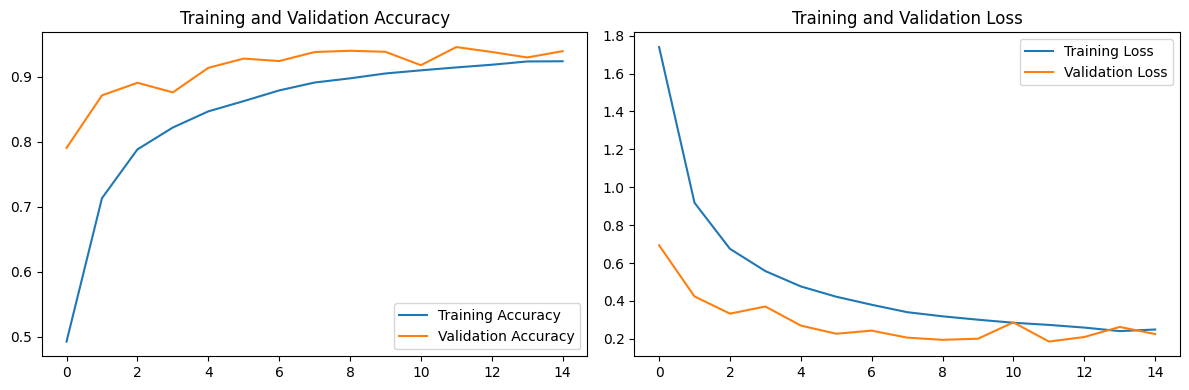

In [21]:
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']

loss = history.history['loss']
val_loss = history.history['val_loss']

# epochs_range = range(8)

plt.figure(figsize=(8,8))
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot( acc, label='Training Accuracy')
plt.plot( val_acc, label='Validation Accuracy')
plt.legend()
plt.title('Training and Validation Accuracy')


plt.subplot(1, 2, 2)
plt.plot( loss, label='Training Loss')
plt.plot( val_loss, label='Validation Loss')
plt.legend()
plt.title('Training and Validation Loss')


plt.tight_layout()
plt.show()


### CONFUSION MATRIX AND F1SCORE

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 342ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step
1/1 ━━━━━━━

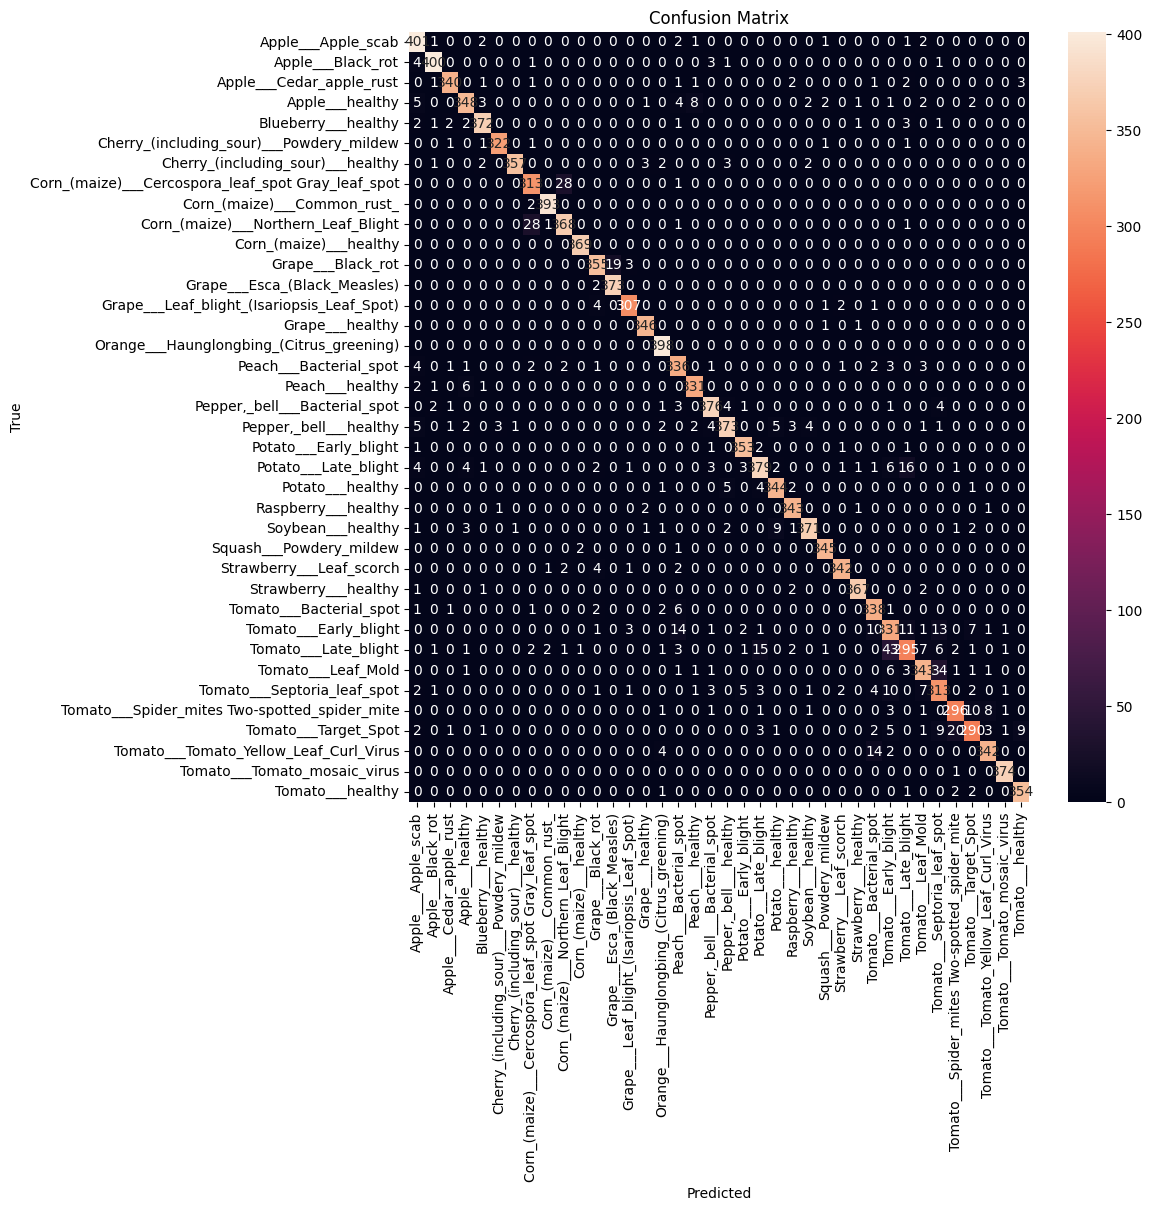

In [22]:
import sklearn
from sklearn.metrics import classification_report, confusion_matrix, f1_score
import numpy as np
import seaborn as sns

y_true = []
y_pred = []

for images, labels in val_ds:
  preds = model.predict(images)
  y_true.extend(labels.numpy())
  y_pred.extend(np.argmax(preds,axis=1))


print(classification_report(y_true, y_pred, target_names=class_names))

cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(10,10))
sns.heatmap(cm,annot=True, fmt='d', xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title("Confusion Matrix")
plt.show()

In [23]:
# Evaluate the model on the validation dataset
validation_loss, validation_accuracy = model.evaluate(val_ds)

# Print the validation loss and accuracy
print("Validation Loss:", validation_loss)
print("Validation Accuracy:", validation_accuracy)

879/879 ━━━━━━━━━━━━━━━━━━━━ 9s 10ms/step - accuracy: 0.9499 - loss: 0.1667
Validation Loss: 0.18564529716968536
Validation Accuracy: 0.9458709955215454


In [24]:
from tensorflow.keras.utils import load_img, img_to_array
import numpy as np

def predict_and_show(model,img_path,target_size=(image_height, image_width)):
    # preprocess
    image = load_img(img_path, target_size=(128, 128))
    img_array = np.expand_dims(image, axis=0)
    # predict
    prediction = model.predict(img_array)
    predicted_class = np.argmax(prediction)
    predicted_label = class_names[predicted_class]
    confidence = prediction[0][predicted_class] * 100
    # show result
    print("Prediction vector:", prediction)
    print("Sum of probabilities:", np.sum(prediction))
    print("Predicted class index:", predicted_class)
    print(f"Prediction: {predicted_label} ({confidence:.2f}%)")
    # Show image with label
    plt.imshow(image)
    plt.title(f"Predicted: {predicted_label}")
    plt.axis('off')
    plt.show()


1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 620ms/step
Prediction vector: [[8.5127994e-08 3.7765130e-04 3.8453093e-10 6.4695103e-14 1.0432691e-10
  2.4442807e-12 2.0650658e-16 3.7274422e-10 1.4638353e-11 1.9773207e-17
  2.9267366e-28 3.9328067e-17 5.5247646e-14 3.8029957e-22 4.1050716e-24
  3.1559622e-20 2.4427581e-07 6.0916312e-14 9.2366427e-01 1.4410260e-06
  2.5096064e-04 2.2352506e-12 1.8866983e-12 4.9013214e-29 2.2292600e-16
  3.4451891e-26 1.2131131e-11 1.5748682e-20 3.7256151e-14 2.6903395e-05
  1.5836230e-07 3.7216756e-09 7.5678363e-02 2.2176034e-26 1.1728733e-11
  7.5896146e-27 1.2638309e-20 2.3547901e-18]]
Sum of probabilities: 1.0000001
Predicted class index: 18
Prediction: Pepper,_bell___Bacterial_spot (92.37%)


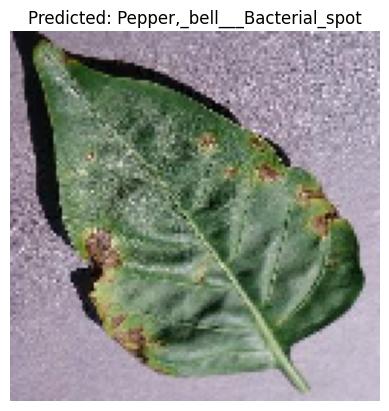

In [25]:
img_path = "/content/plant-disease-dataset/new plant diseases dataset(augmented)/New Plant Diseases Dataset(Augmented)/train/Pepper,_bell___Bacterial_spot/00f2e69a-1e56-412d-8a79-fdce794a17e4___JR_B.Spot 3132.JPG"
predict_and_show(model, img_path)

In [32]:
# function for predictions
def show_predictions(model,dataset,num_images=12):
    plt.figure(figsize=(15,13))
    for images , label in dataset.take(1):
         prediction = model.predict(images)
         predicted_class = np.argmax(prediction,axis=1)
         for i in range(num_images):
             ax = plt.subplot(4,3,i+1)
             plt.imshow(images[i].numpy().astype('uint8'))
             true_label = class_names[label[i]]
             predicted_label = class_names[predicted_class[i]]
             plt.title(f"True: {true_label}\n Predicted: {predicted_label}")
             plt.axis('off')


    plt.tight_layout()
    plt.show()


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step


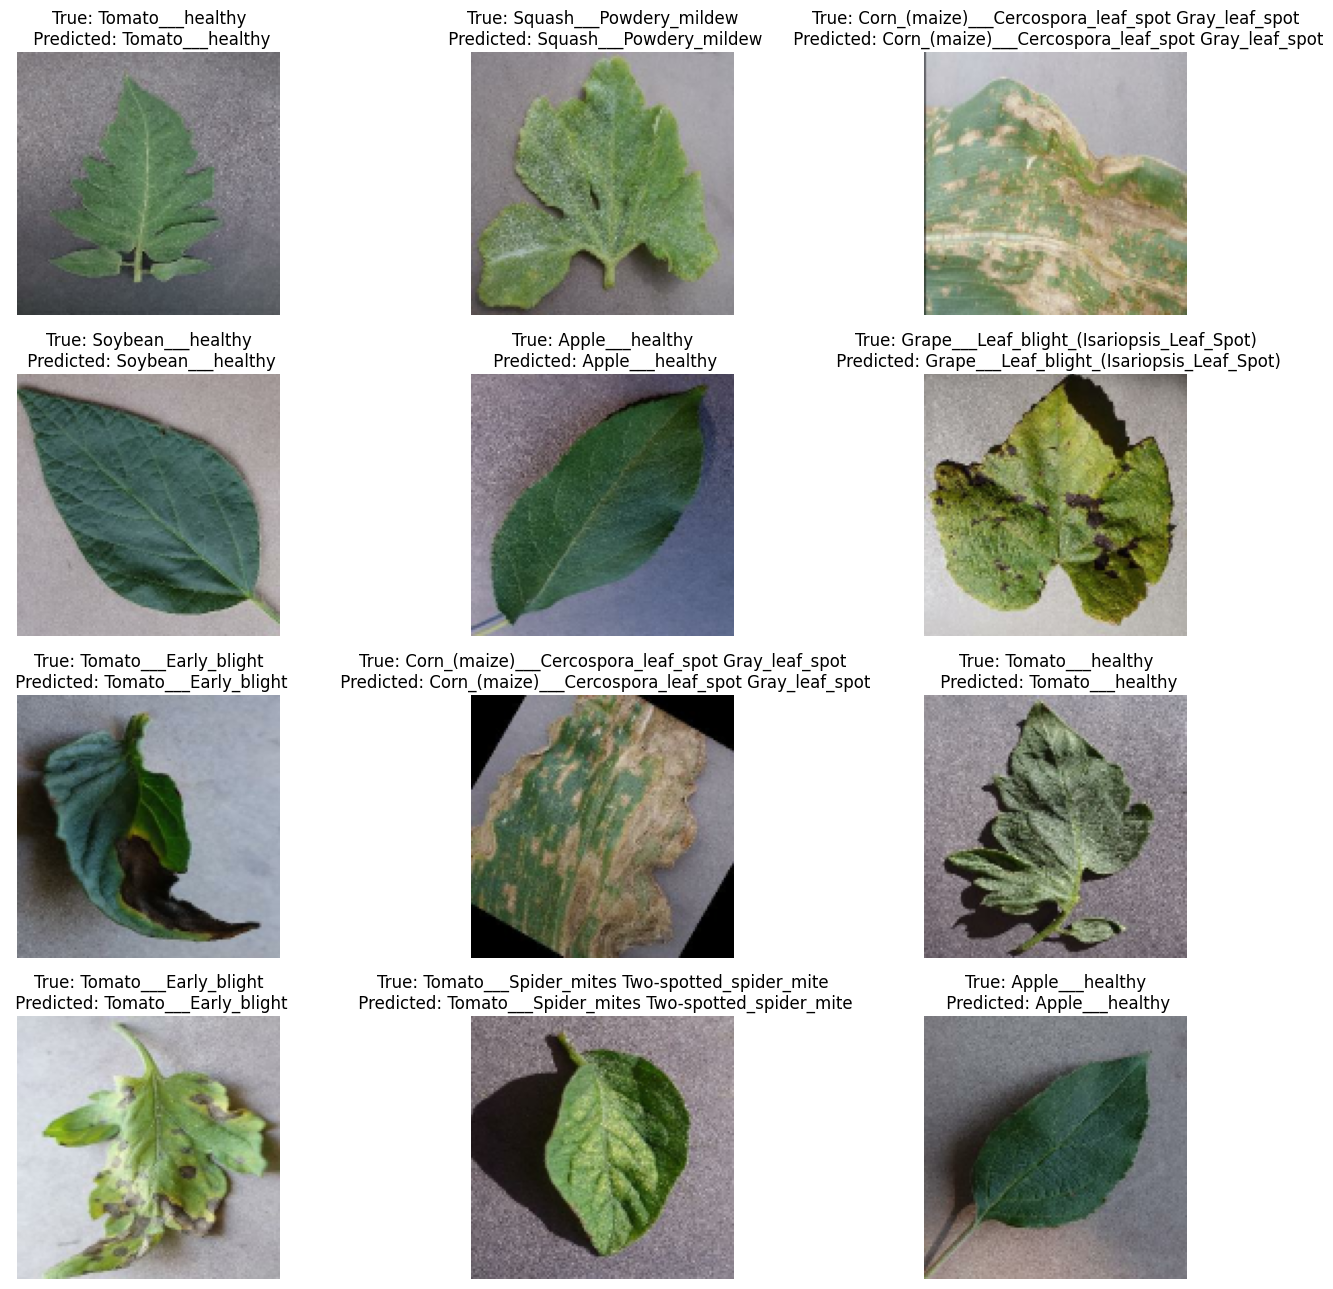

In [33]:
show_predictions(model=model,dataset=train_ds,num_images=12)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step


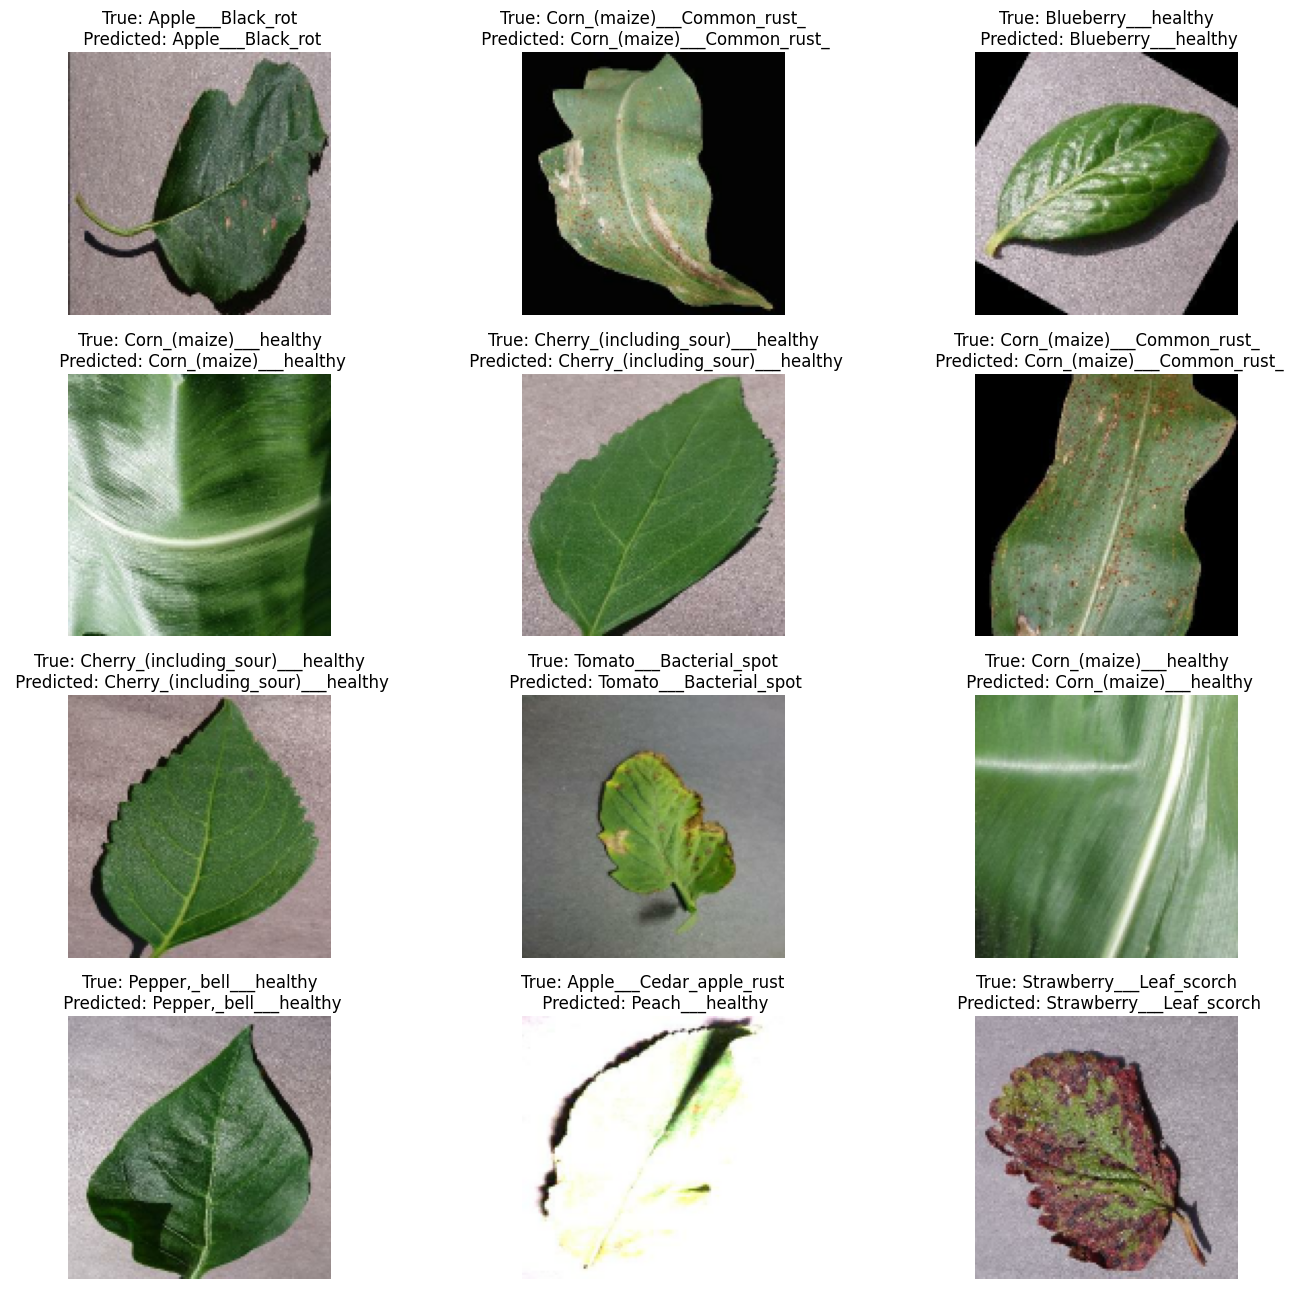

In [34]:
# prediction on validation dataset
show_predictions(model=model,dataset=val_ds,num_images=12)

In [35]:
class_names

['Apple___Apple_scab',
 'Apple___Black_rot',
 'Apple___Cedar_apple_rust',
 'Apple___healthy',
 'Blueberry___healthy',
 'Cherry_(including_sour)___Powdery_mildew',
 'Cherry_(including_sour)___healthy',
 'Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot',
 'Corn_(maize)___Common_rust_',
 'Corn_(maize)___Northern_Leaf_Blight',
 'Corn_(maize)___healthy',
 'Grape___Black_rot',
 'Grape___Esca_(Black_Measles)',
 'Grape___Leaf_blight_(Isariopsis_Leaf_Spot)',
 'Grape___healthy',
 'Orange___Haunglongbing_(Citrus_greening)',
 'Peach___Bacterial_spot',
 'Peach___healthy',
 'Pepper,_bell___Bacterial_spot',
 'Pepper,_bell___healthy',
 'Potato___Early_blight',
 'Potato___Late_blight',
 'Potato___healthy',
 'Raspberry___healthy',
 'Soybean___healthy',
 'Squash___Powdery_mildew',
 'Strawberry___Leaf_scorch',
 'Strawberry___healthy',
 'Tomato___Bacterial_spot',
 'Tomato___Early_blight',
 'Tomato___Late_blight',
 'Tomato___Leaf_Mold',
 'Tomato___Septoria_leaf_spot',
 'Tomato___Spider_mites Two-spotted_

In [36]:
import json
with open('class_names.json', 'w') as f:
    json.dump(class_names, f)


In [38]:
# saving the model
model.save('plant_disease_model.keras')

In [39]:
# save the weights
model.save_weights("plant_disease_model.weights.h5")

In [30]:
# from google.colab import files
# files.download("plant_disease_model.keras")


In [31]:
import pandas as pd


print("Numpy Version:", np.__version__)
print("Pandas version:", pd.__version__)
print("Scikit-learn version:", sklearn.__version__)
print("TensorFlow version:", tf.__version__)


Numpy Version: 2.0.2
Pandas version: 2.2.2
Scikit-learn version: 1.6.1
TensorFlow version: 2.18.0
